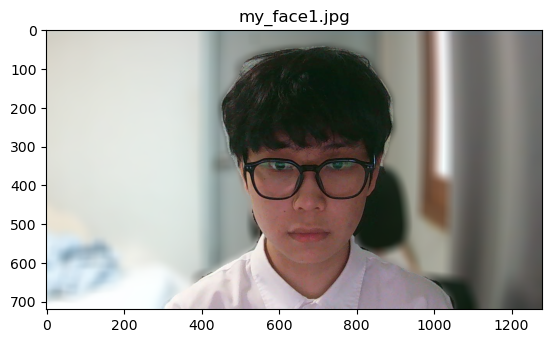

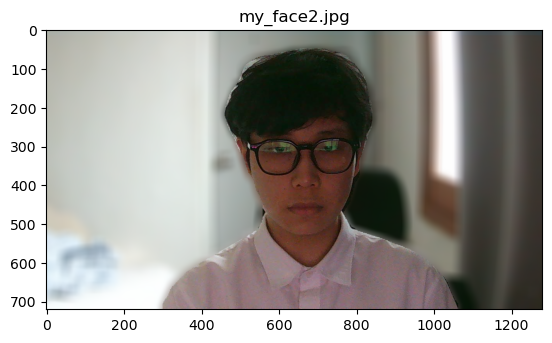

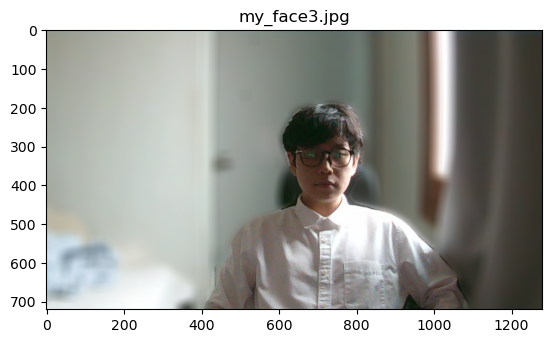

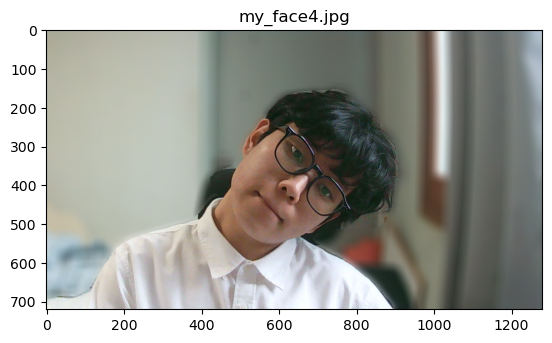

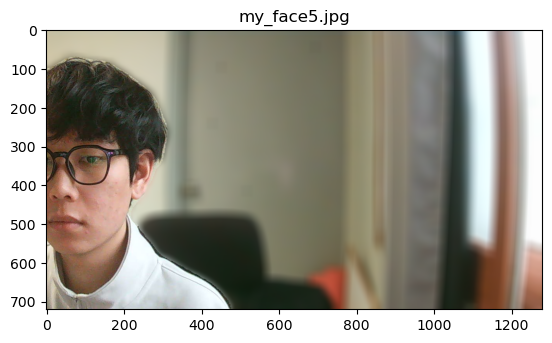

In [6]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
import matplotlib.pyplot as plt

home_dir = os.getenv('HOME')
model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).eval()

def portrait_mode(img_path):
    img_orig = cv2.imread(img_path)

    transform = T.Compose([
        T.ToPILImage(),
        T.Resize((520, 520)),
        T.ToTensor(),
    ])

    input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)
    with torch.no_grad():
        output = model(input_tensor)["out"][0]
        output_predictions = output.argmax(0).byte().cpu().numpy()

    output_predictions_resized = cv2.resize(
        output_predictions,
        (img_orig.shape[1], img_orig.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    seg_map = (output_predictions_resized == 15)
    img_mask = seg_map.astype(np.uint8) * 255
    img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

    img_orig_blur = cv2.blur(img_orig, (30, 30))
    img_bg_mask = cv2.bitwise_not(img_mask_color)
    img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)

    img_result = np.where(img_mask_color==255, img_orig, img_bg_blur)

    plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(img_path))
    plt.show()

portrait_mode(os.path.join(home_dir, "work/workplace/AIFFEL_quest_eng/Computer_Vision/CV02/my_face1.jpg"))
portrait_mode(os.path.join(home_dir, "work/workplace/AIFFEL_quest_eng/Computer_Vision/CV02/my_face2.jpg"))
portrait_mode(os.path.join(home_dir, "work/workplace/AIFFEL_quest_eng/Computer_Vision/CV02/my_face3.jpg"))
portrait_mode(os.path.join(home_dir, "work/workplace/AIFFEL_quest_eng/Computer_Vision/CV02/my_face4.jpg"))
portrait_mode(os.path.join(home_dir, "work/workplace/AIFFEL_quest_eng/Computer_Vision/CV02/my_face5.jpg"))

원본 고양이 이미지 크기: (462, 432, 3)
배경(사막) 이미지 크기: (426, 640, 3)


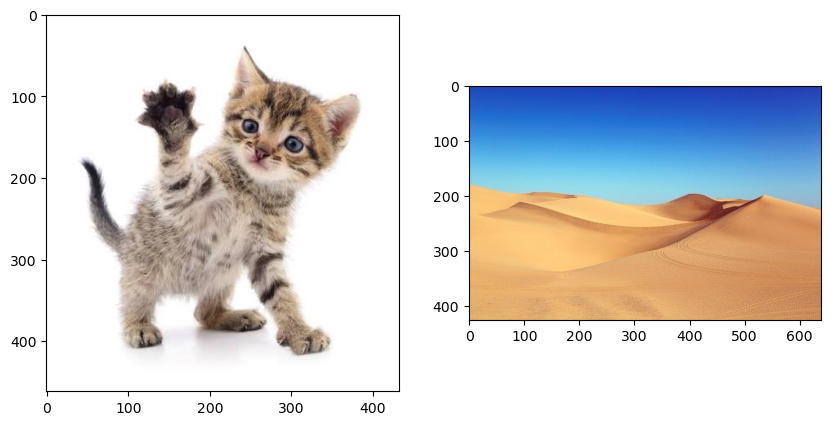

In [7]:
cat_img_path = "cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [8]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [9]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (462, 432)


In [10]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


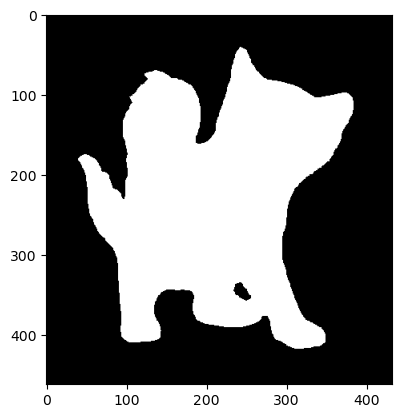

In [11]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

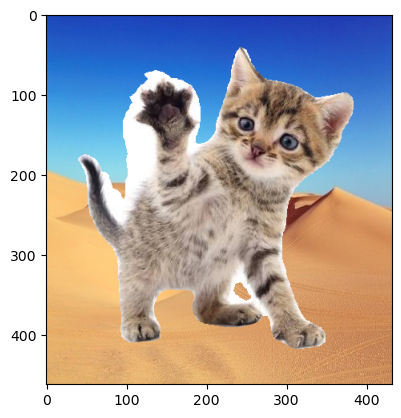

In [12]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

### 사진에서 문제점 찾기

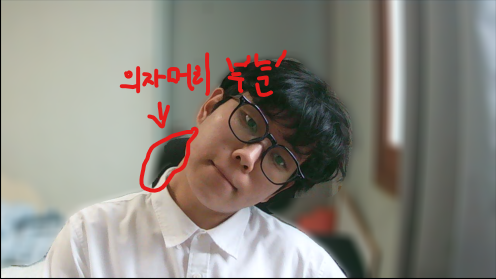
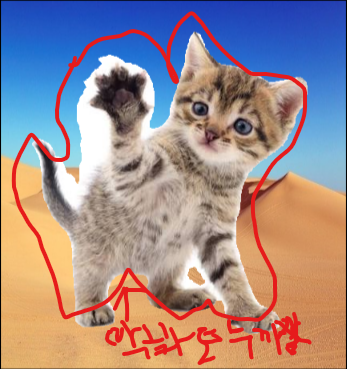

문제점 1: 의자가 블러 처리 안 됨

원인:
DeepLab은 픽셀 하나하나를 독립적으로 분류한다.
얼굴 바로 옆에 의자가 있으면
의자 픽셀이 사람 픽셀이랑 가까이 있어서
"이것도 사람이겠지" 하고 잘못 분류함.
결과적으로 의자가 사람 마스크에 포함돼서
블러 처리가 안됨

해결 - CRF:
CRF는 마스크 경계선을 다듬는 기법이에요.
"비슷한 색깔 픽셀끼리는 같은 영역이다" 라는 규칙으로
의자 색이 배경이랑 비슷하면 배경으로 재분류한다.
즉 DeepLab이 만든 마스크에 CRF를 추가로 적용해서
잘못 포함된 의자 픽셀을 배경으로 돌려보내는 거

문제점 2: 고양이 누끼 모서리 배경 잔상

원인:
DeepLab이 고양이 픽셀을 찾을 때
경계선 부분은 "고양이인지 배경인지" 애매해진다.
그래서 경계선 픽셀이 고양이로 분류됐다가
실제로는 배경 색깔이 섞여있어서
누끼 모서리에 원본 배경 색이 조금씩 남는다.

해결 - Erosion:
Erosion은 마스크를 안쪽으로 조금 줄이는 거예요.
경계선 픽셀을 마스크에서 제거하는 효과예요.
애매한 경계선 픽셀들이 날아가니까
모서리에 남아있던 배경 잔상이 사라진다
DeepLab 마스크에 Erosion을 적용하면
고양이 안쪽 픽셀만 남아서 더 깔끔한 누끼가 따진다.


회고: 원인을 찾고 해결방안을 찾았지만 직접 아직 적용을 못시켜 본부분이 아쉽다 그리고 사람을 2명이상인 사진을 못사용한게 아쉽다